This notebook performs Exploratory Data Analysis (EDA) on the RACE dataset. 
The goal is to understand dataset structure, distribution, and characteristics 
to inform preprocessing and model design decisions.

In [14]:
train_df = pd.read_csv('train.csv', engine='python', on_bad_lines='skip')
val_df   = pd.read_csv('val.csv', engine='python', on_bad_lines='skip')
test_df  = pd.read_csv('test.csv', engine='python', on_bad_lines='skip')

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (64396, 9)
Val shape:   (61833, 9)
Test shape:  (77962, 9)


In [15]:
print("Duplicate rows:", train_df.duplicated().sum())

print("Empty articles:", train_df['article'].eq('').sum())
print("Empty questions:", train_df['question'].eq('').sum())

Duplicate rows: 0
Empty articles: 0
Empty questions: 0


answer
A    14083
B    16673
C    17547
D    16092
Name: count, dtype: int64


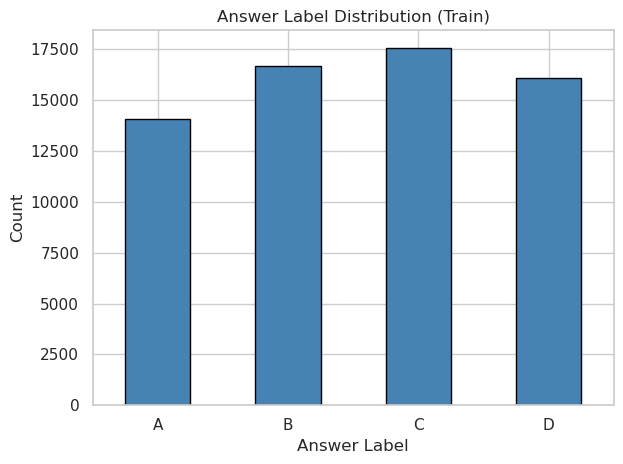

In [16]:
answer_counts = train_df['answer'].value_counts().sort_index()
print(answer_counts)

answer_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Answer Label Distribution (Train)')
plt.xlabel('Answer Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The answer labels are relatively well distributed across all four classes (A, B, C, D), 
with a slight skew toward options B (16,673) and C (17,547). While the dataset is not 
perfectly balanced, the imbalance is not severe enough to require aggressive resampling. 
However, evaluation metrics such as F1-score should still be considered alongside accuracy 
to account for this minor skew.

count    64396.000000
mean       263.169498
std         99.649047
min          2.000000
25%        198.000000
50%        268.000000
75%        319.000000
max       1162.000000
Name: article_word_count, dtype: float64


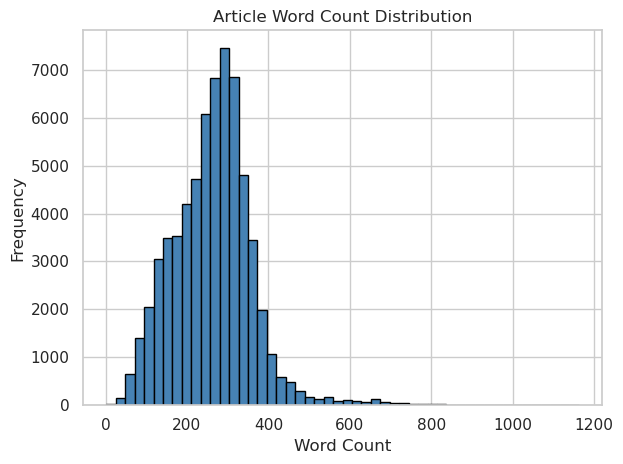

In [26]:
train_df['article_word_count'] = train_df['article'].str.split().str.len()

print(train_df['article_word_count'].describe())

train_df['article_word_count'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Article Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The average article length is approximately 263 words, with a wide range from very short 
passages (2 words) to very long ones (over 1100 words). The relatively high standard deviation 
(~99 words) indicates significant variability in passage length. This has important implications 
for feature engineering, as longer articles will increase vocabulary size and computational cost. 
Therefore, techniques such as limiting maximum features or truncating text may be necessary.

count    64396.000000
mean         9.859230
std          3.399828
min          1.000000
25%          7.000000
50%          9.000000
75%         12.000000
max         63.000000
Name: question_word_count, dtype: float64


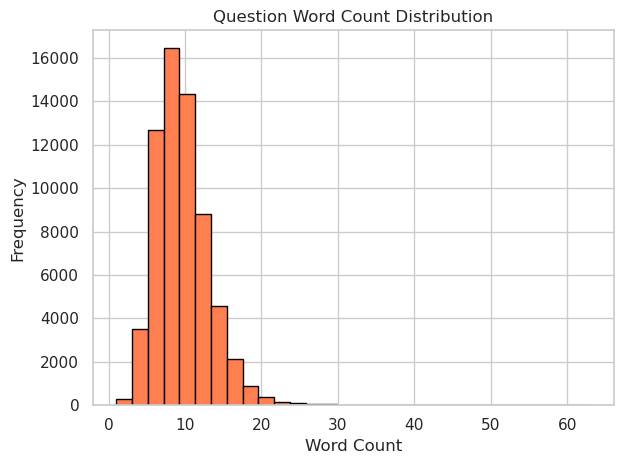

In [27]:
train_df['question_word_count'] = train_df['question'].str.split().str.len()

print(train_df['question_word_count'].describe())

train_df['question_word_count'].plot(kind='hist', bins=30, color='coral', edgecolor='black')
plt.title('Question Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Questions are relatively short, with an average length of approximately 10 words and low 
variance. Most questions fall within a narrow range (7–12 words), indicating a consistent 
structure across the dataset. This suggests that the semantic complexity of the task is 
primarily driven by the article rather than the question itself.

In [20]:
for col in ['A', 'B', 'C', 'D']:
    train_df[f'{col}_word_count'] = train_df[col].str.split().str.len()

option_lengths = train_df[['A_word_count', 'B_word_count', 'C_word_count', 'D_word_count']]
option_lengths.describe()

,A_word_count,B_word_count,C_word_count,D_word_count
count,64393.000000,64395.000000,64394.000000,64387.000000
mean,5.260417,5.455967,5.619142,5.739186
std,3.291814,3.399747,3.472637,3.559539
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000
50%,5.000000,5.000000,5.000000,5.000000
75%,7.000000,8.000000,8.000000,8.000000
max,91.000000,105.000000,48.000000,56.000000


Answer options across A, B, C, and D have similar average lengths (approximately 5–6 words), 
indicating a balanced design with no significant bias toward longer or shorter options. 
However, the presence of extreme outliers (e.g., options exceeding 90 words) suggests that 
some answers may contain full phrases or sentences. These outliers should be handled carefully 
during preprocessing to avoid skewing feature representations.

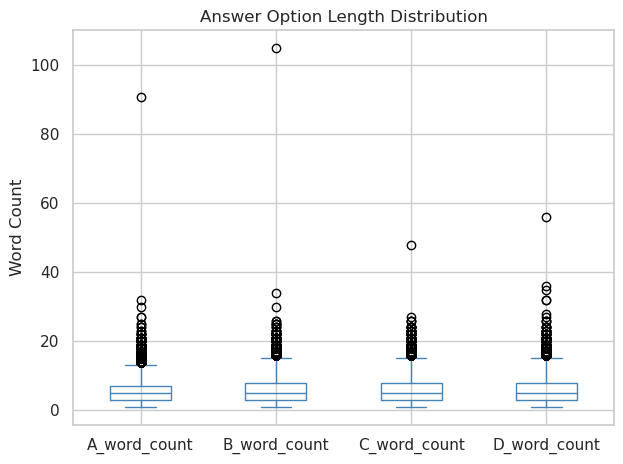

In [21]:
option_lengths.plot(kind='box', color='steelblue')
plt.title('Answer Option Length Distribution')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

question_type
other    36847
what     10532
which     7771
why       2998
how       2714
when      1711
who        922
where      901
Name: count, dtype: int64


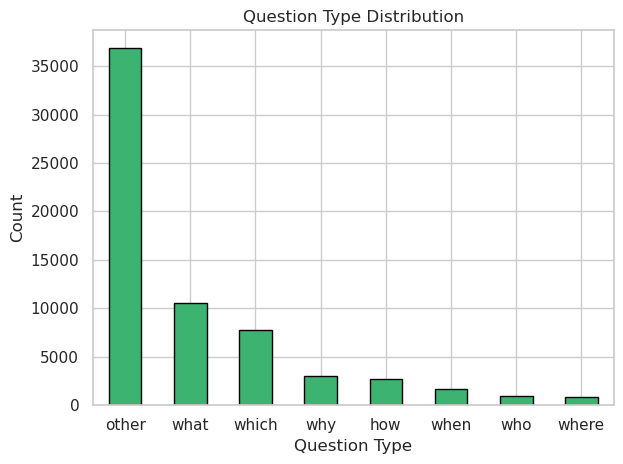

In [22]:
wh_words = ['what', 'who', 'where', 'when', 'why', 'how', 'which']

def get_question_type(q):
    first_word = str(q).lower().split()[0] if pd.notnull(q) else 'other'
    return first_word if first_word in wh_words else 'other'

train_df['question_type'] = train_df['question'].apply(get_question_type)

qtype_counts = train_df['question_type'].value_counts()
print(qtype_counts)

qtype_counts.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Question Type Distribution')
plt.xlabel('Question Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A large portion of questions (36,847) fall under the 'other' category, meaning they do not 
start with standard Wh-words. Among the identifiable types, 'what' (10,532) and 'which' (7,771) 
are the most common, while 'who' and 'where' are relatively rare. This indicates that many 
questions may follow non-standard formats or begin with auxiliary verbs. For template-based 
question generation, focusing on 'what' and 'which' patterns will likely yield the most coverage.

In [23]:
blank_count = train_df['question'].str.strip().eq('_').sum()
total = len(train_df)
print(f"Blank-fill questions: {blank_count} ({100*blank_count/total:.1f}%)")
print(f"Normal questions:     {total - blank_count} ({100*(total-blank_count)/total:.1f}%)")

Blank-fill questions: 2 (0.0%)
Normal questions:     64394 (100.0%)


Only 2 questions in the dataset are fill-in-the-blank type, representing effectively 0% 
of the data. This indicates that the dataset primarily consists of standard multiple-choice 
questions, and no special handling for blank-fill questions is required in the modeling pipeline.

In [24]:
summary = {
    'Split': ['Train', 'Val', 'Test'],
    'Rows': [len(train_df), len(val_df), len(test_df)],
    'Avg Article Words': [
        train_df['article_word_count'].mean().round(1),
        val_df['article'].str.split().str.len().mean().round(1),
        test_df['article'].str.split().str.len().mean().round(1)
    ],
    'Avg Question Words': [
        train_df['question_word_count'].mean().round(1),
        val_df['question'].str.split().str.len().mean().round(1),
        test_df['question'].str.split().str.len().mean().round(1)
    ]
}

pd.DataFrame(summary)

,Split,Rows,Avg Article Words,Avg Question Words
0,Train,64396,263.2,9.9
1,Val,61833,261.1,9.8
2,Test,77962,271.0,10.0


The dataset is well-distributed across training, validation, and test splits, with consistent 
average article lengths (~260–270 words) and question lengths (~10 words) across all splits. 
This consistency suggests that the data is well-prepared and that models trained on the training 
set are likely to generalize effectively to validation and test sets without distribution shift.